## 10.1 LSTM - 核心结构

#### 1、什么是 LSTM

##### 1.1 LSTM 的本质是什么
LSTM 的全称是 Long Short-Term Memory，中文通常叫作 长短期记忆网络。

它是一种 **特殊设计的 RNN（循环神经网络）**，目的就是解决普通 RNN 在处理长序列时，长期信息难以保留的问题。

我们前面已经学过，普通 RNN 会在时间步之间不断传递隐藏状态：

$h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b)$

这种结构虽然可以处理序列，但在序列变长之后，前面时刻的重要信息在不断传播中容易：

- 被逐渐淡化 😵
- 被后面的信息覆盖 😵‍💫
- 在反向传播时出现梯度消失 😵‍💥

所以，普通 RNN 更擅长处理 **短期依赖**，但对于：

- 句子开头的信息影响句子结尾
- 很久之前的时间点影响当前预测
- 上下文跨度很长的语言任务

就会比较吃力。

而 LSTM 就是专门为这个问题设计的。

##### 1.2 LSTM 想解决什么问题
LSTM 主要想解决的是：

如何让模型在序列中：

- 该记住的记住
- 该忘掉的忘掉
- 该输出的输出

也就是说，LSTM 不再像普通 RNN 那样，直接把所有信息都混在一个隐藏状态里反复传递；

而是增加了一套 **门控机制（Gating Mechanism）**，像“信息管理员”一样，专门决定：

- 哪些旧信息要保留 ✅
- 哪些旧信息要丢弃 ❌
- 哪些新信息要写入 📝
- 哪些内部记忆要暴露给外部输出 👀

所以，LSTM 可以理解为：

>在普通 RNN 的基础上，增加了一条更稳定的记忆通道，并用多个门来控制信息流动。

##### 1.3 LSTM 名字中“长短期记忆”是什么意思
LSTM 这个名字非常形象。

**Short-Term Memory（短期记忆）**：可以理解为当前时刻对外暴露的隐藏状态 $h_t$

**Long-Term Memory（长期记忆）**：可以理解为贯穿序列传递的单元状态 $C_t$

其中：

- $h_t$：更像“当前脑海里正在想什么”
- $C_t$：更像“心里一直记着的重要信息”

所以 LSTM 有两套状态：

- 隐藏状态 $h_t$：用于当前输出，也传给下一时刻
- 细胞状态 $C_t$：作为更核心、更稳定的长期记忆通道

这就是 LSTM 与普通 RNN 最大的结构区别之一。


#### 2、LSTM 的改进思路

##### 2.1 增加一条专门的记忆通道
LSTM 引入了 **细胞状态 $C_t$**，它像一条横向贯穿整个时间序列的“高速通道”。

它具备这些特点：

- 可以跨越很多时间步传递信息
- 不会每次都被完全重新计算
- 只会在门控的控制下做“保留、删除、增加”这些相对温和的更新

这使得长期信息更容易保存。

##### 2.2 增加多个门来精细控制信息流
LSTM 不再粗暴地把所有信息一起更新，而是增加了三个核心门：

- 遗忘门：决定旧记忆保留多少
- 输入门：决定新信息写入多少
- 输出门：决定当前要输出多少内部记忆

所以 LSTM 的信息流动是“有选择的”，而不是“全部通过”。

这就像你记笔记时不会把所有内容都记住，而是会：

- 删掉不重要的
- 记下有价值的
- 在需要回答问题时提取一部分表达出来

这就是门控结构的直观含义。

#### 3、LSTM 的核心结构总览

##### 3.1 LSTM 中有哪几个核心变量
在每一个时间步 $t$，LSTM 的输入和输出主要包括下面这些变量：

**输入部分**

- 当前输入：$x_t$
- 上一时刻隐藏状态：$h_{t-1}$
- 上一时刻细胞状态：$C_{t-1}$

**输出部分**

- 当前隐藏状态：$h_t$
- 当前细胞状态：$C_t$

所以 LSTM 每一步不是只传一个状态，而是传两个状态：

- $h_t$
- $C_t$

这点非常重要。

##### 3.2 两条主线：隐藏状态和细胞状态
我们可以把 LSTM 看成有两条并行的信息流。

**（1）隐藏状态 $h_t$**

- 对外部可见
- 用于当前时刻输出
- 也传递给下一个时间步
- 更偏“短期工作记忆”

**（2）细胞状态 $C_t$**

- 是 LSTM 内部更核心的记忆载体
- 主要用于长期信息保存
- 沿时间维稳定传递
- 更偏“长期记忆”

所以，LSTM 的精髓不是单纯有更多参数，而是：

它把“对外输出”和“内部长期记忆”分开管理了。

##### 3.3 LSTM 的结构图应该如何理解
通常 LSTM 结构图中：

![The repeating module in a standard R.NN contains a single layer..png](<attachment:The repeating module in a standard R.NN contains a single layer..png>)

![The repeating module in an LSTM contains four interacting layers..png](<attachment:The repeating module in an LSTM contains four interacting layers..png>)

![Screenshot 2026-04-15 at 17.23.17.png](<attachment:Screenshot 2026-04-15 at 17.23.17.png>)

- 上面一条横着贯穿的线：就是细胞状态 $C_t$ 的传递路径
- 下面多个门结构：用于控制信息进入、离开、保留
- 当前输入 $x_t$ 和上一时刻隐藏状态 $h_{t-1}$ 往往会先拼接，再送入各个门中

也就是说，LSTM 每个时间步内部不是一个简单计算单元，而是一个 **小型的信息控制系统**。
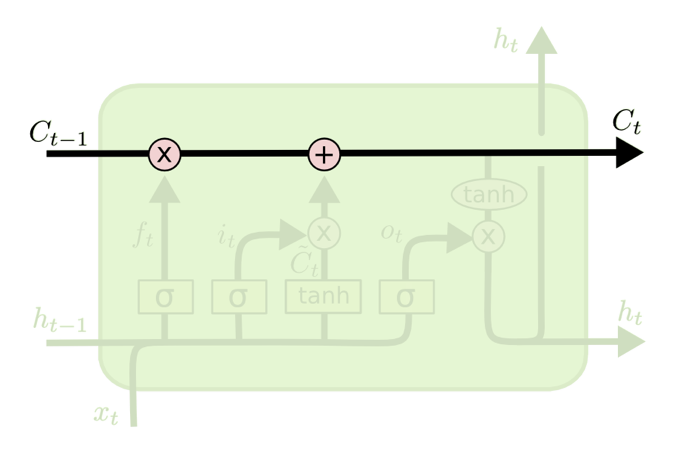
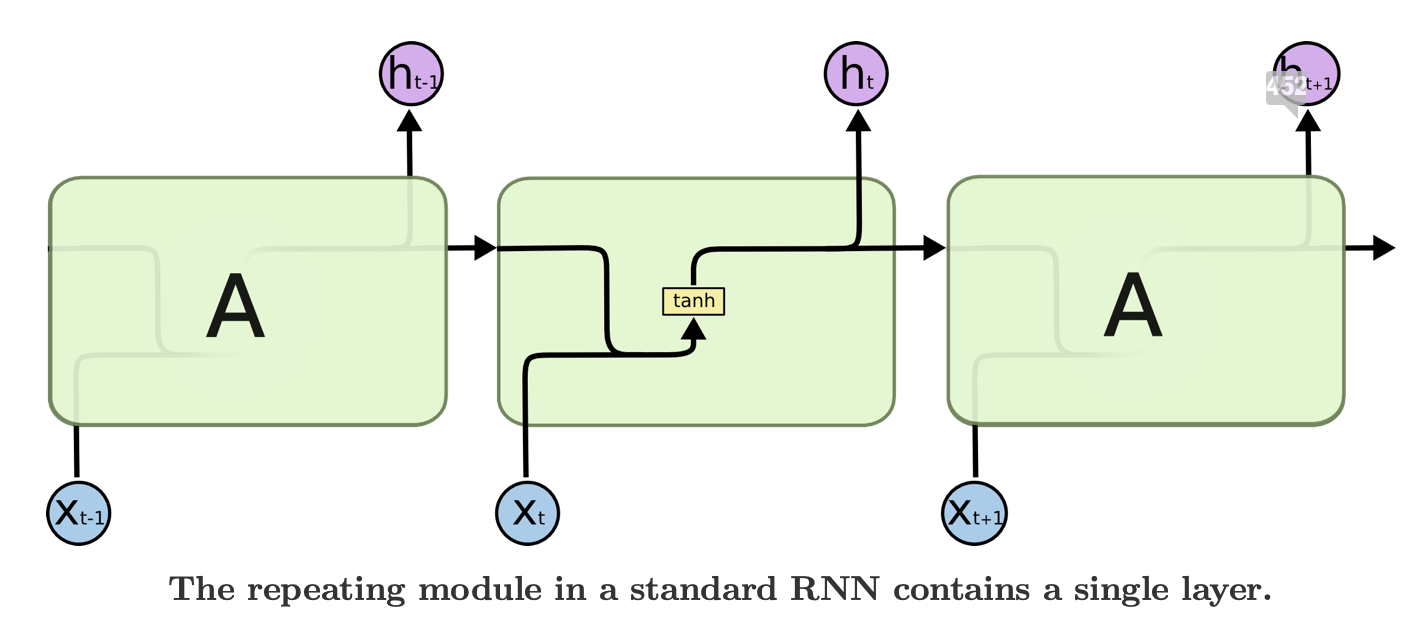
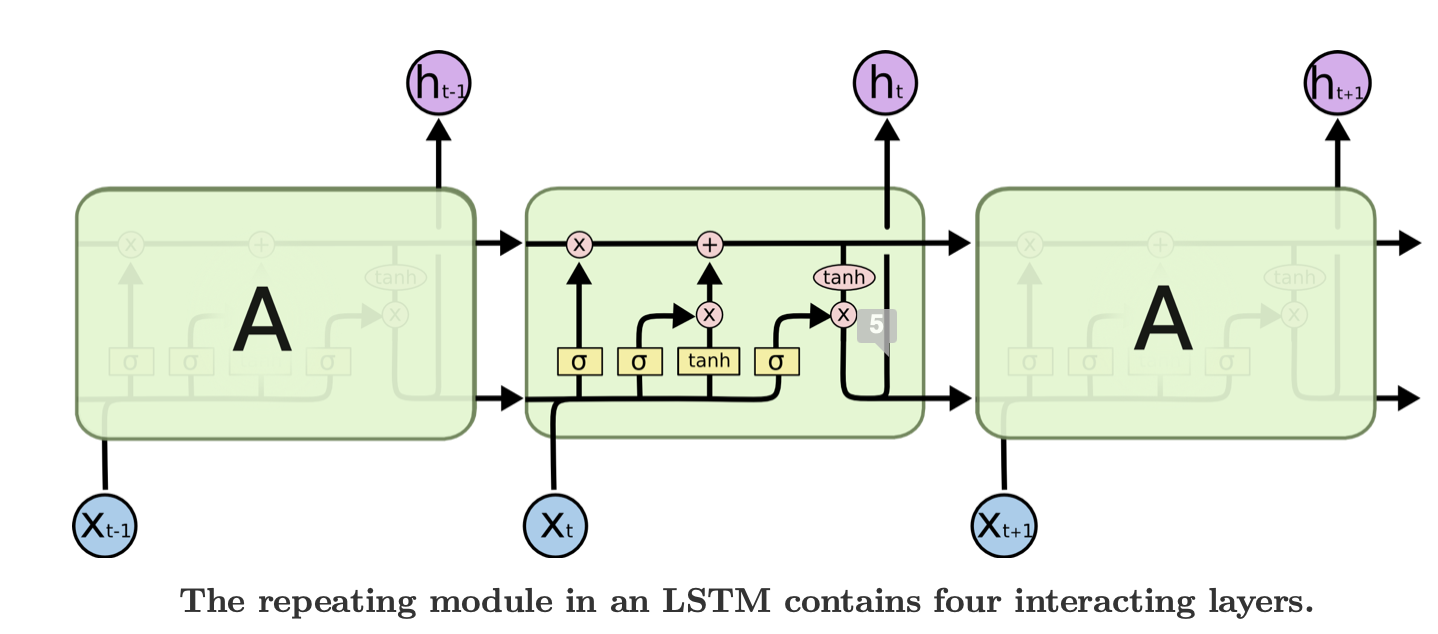

#### 4、LSTM 的三个核心门

##### 4.1 遗忘门 Forget Gate

**作用**

遗忘门决定：

上一时刻的细胞状态 $C_{t-1}$ 中，有多少内容应该保留到当前时刻 $C_t$。

它的公式通常写作：

$f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)$

其中：

- $[h_{t-1}, x_t]$ 表示拼接输入和当前隐藏状态
- $W_f$ 是遗忘门权重
- $b_f$ 是偏置
- $f_t$ 的每个元素都在 `0 到 1` 之间

理解为：

- $f_t = 1$：这一部分旧记忆全部保留
- $f_t = 0$：这一部分旧记忆完全忘掉
- $0 < f_t < 1$：保留一部分

所以，遗忘门是 LSTM 的“删减器”。


##### 4.2 输入门 Input Gate

**作用**

输入门决定：

当前时刻产生的新信息，有多少可以写入到当前细胞状态 $C_t$ 中。

它通常分成两部分：

**（1）输入门系数**

$i_t = \sigma(W_i[h_{t-1}, x_t] + b_i)$

用于决定“写入多少”。

**（2）候选记忆**

$\tilde{C}_t = \tanh(W_c[h_{t-1}, x_t] + b_c)$

用于生成“要写入什么内容”。

这里：

- $i_t$ 决定写入比例
- 候选记忆 $\tilde{C}_t$ 提供候选内容


##### 4.3 输出门 Output Gate

**作用**

输出门决定：

当前细胞状态 $C_t$ 中的哪些信息，可以作为当前隐藏状态 $h_t$ 输出出去。

它的公式通常写作：

$o_t = \sigma(W_o[h_{t-1}, x_t] + b_o)$

然后结合细胞状态得到隐藏状态：

$h_t = o_t \odot \tanh(C_t)$

这里的意思是：

- 先把当前细胞状态 $C_t$ 通过 `tanh` 压缩到合适范围
- 再由输出门 $o_t$ 控制哪些部分真正输出

所以输出门是 LSTM 的“表达器”。

#### 5、LSTM 的细胞状态是如何更新的

##### 5.1 细胞状态更新公式
LSTM 最关键的公式之一是：

$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$

这个公式非常值得反复理解。

它表示当前细胞状态由两部分组成：

- 遗忘门保留下来的旧记忆
- 输入门决定写入的新记忆

不是完全覆盖，而是“有选择地更新”。

##### 5.2 这个更新方式为什么好
这个更新方式比普通 RNN 更稳定，因为它不是每一步都完全重新生成记忆，而是：

- 先决定保留多少旧内容
- 再决定加入多少新内容

因此，细胞状态的更新更像“渐进修改”，而不是“彻底改写”。

这使得长期依赖更容易保留。

#### 6、LSTM 简要单时间步计算流程

##### 6.1 按顺序来看每一步
在时间步 $t$，LSTM 一般按下面顺序工作：

**第一步：计算遗忘门**

$f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)$

决定旧记忆保留多少。

**第二步：计算输入门**

$i_t = \sigma(W_i[h_{t-1}, x_t] + b_i)$

决定新记忆写入多少。

**第三步：计算候选记忆**

$\tilde{C}_t = \tanh(W_c[h_{t-1}, x_t] + b_c)$

生成当前候选内容。

**第四步：更新细胞状态**

$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$

形成新的长期记忆。

**第五步：计算输出门**

$o_t = \sigma(W_o[h_{t-1}, x_t] + b_o)$

决定哪些内部记忆用于输出。

**第六步：生成隐藏状态**

$h_t = o_t \odot \tanh(C_t)$

得到当前时刻输出。

##### 6.2 用一句话总结整个流程
LSTM 每一步都在做这件事：

先忘掉一部分旧记忆，再写入一部分新记忆，最后从当前记忆中挑出一部分作为输出。

#### 7、LSTM 和普通 RNN 对比

##### 7.1 普通 RNN 的特点

- 只有一个隐藏状态 $h_t$
- 所有信息混在一起更新
- 结构简单
- 适合短依赖
- 长序列时容易梯度消失

##### 7.2 LSTM 的特点

- 有两个状态：$h_t$ 和 $C_t$
- 有门控机制精细控制信息流
- 可以更好保留长期依赖
- 结构更复杂，参数更多
- 训练成本高于普通 RNN，但效果通常更好

##### 7.3 最核心的区别
普通 RNN：只有“状态更新”

LSTM：不仅更新状态，还管理记忆

也可以说：

- 普通 RNN 更像“边走边忘”
- LSTM 更像“边走边整理记忆”